Mapeo de categorías: {'negative': 0, 'neutral': 1, 'positive': 2}
              precision    recall  f1-score   support

    negative       0.67      0.53      0.59        92
     neutral       0.58      0.58      0.58        97
    positive       0.87      0.90      0.89       504

    accuracy                           0.81       693
   macro avg       0.71      0.67      0.69       693
weighted avg       0.80      0.81      0.81       693

CV Accuracy : 0.8346 ± 0.0179
CV F1-Macro : 0.7261 ± 0.0216


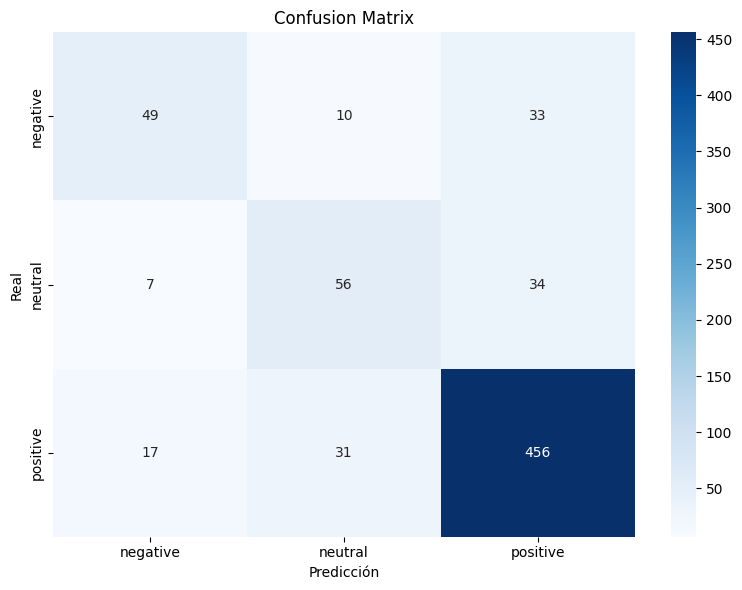

Resultados guardados en /results


<Figure size 640x480 with 0 Axes>

In [ ]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# ── 1. Carga de datos
df = pd.read_csv("EcoPreprocessed.csv")
df = df[["review", "division"]]

# ── 2. Preprocesamiento
# Se eliminan nulos y duplicados antes de limpiar el texto para evitar errores
df = df.dropna(subset=["review", "division"])
df = df.drop_duplicates(subset=["review"])

def clean(text):
    """Normaliza el texto: minúsculas, sin URLs, sin caracteres especiales."""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)  # elimina URLs
    text = re.sub(r"[^a-z\s]", "", text)                 # elimina caracteres especiales
    text = re.sub(r"\s+", " ", text).strip()             # elimina espacios extra
    return text

df["review"] = df["review"].apply(clean)

# ── 3. Encoding de etiquetas
# LabelEncoder convierte las categorías (positive, negative, neutral) a números
# porque LinearSVC requiere etiquetas numéricas
le = LabelEncoder()
df["division"] = le.fit_transform(df["division"])

label_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print("Mapeo de categorías:", label_mapping)

# ── 4. Split
# stratify=y garantiza que cada split mantenga la proporción de clases original
X = df["review"]
y = df["division"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 5. Modelo
# Pipeline encadena TF-IDF + LinearSVC para evitar fuga de datos en la validación
# TfidfVectorizer convierte el texto a vectores numéricos ponderados por relevancia
# LinearSVC es eficiente para clasificación de texto con muchas dimensiones
modelo = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_df=0.95,
        min_df=2,
        ngram_range=(1, 2),
        sublinear_tf=True
    )),
    ("clf", LinearSVC(class_weight="balanced", max_iter=1000))
])

modelo.fit(X_train, y_train)   # entrena con el 80% de los datos
pred = modelo.predict(X_test)  # predice sobre el 20% restante (datos no vistos)

# ── 6. Métricas
print(classification_report(y_test, pred, target_names=le.classes_))

# Validación cruzada con 5 folds para medir estabilidad del modelo
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc = cross_val_score(modelo, X, y, cv=cv, scoring="accuracy")
f1  = cross_val_score(modelo, X, y, cv=cv, scoring="f1_macro")

print(f"CV Accuracy : {acc.mean():.4f} ± {acc.std():.4f}")
print(f"CV F1-Macro : {f1.mean():.4f} ± {f1.std():.4f}")

# ── 7. Confusion Matrix
# Muestra cuántas predicciones acertó y falló el modelo por cada categoría
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.tight_layout()
plt.show()

# ── 8. Guardar resultados
os.makedirs("results", exist_ok=True)

report = classification_report(y_test, pred, target_names=le.classes_, output_dict=True)
pd.DataFrame(report).transpose().to_csv("results/classification_report.csv")

pd.DataFrame({
    "fold"    : range(1, 6),
    "accuracy": acc,
    "f1_macro": f1
}).to_csv("results/cv_results.csv", index=False)

plt.savefig("results/confusion_matrix.png", dpi=150, bbox_inches="tight")

print("Resultados guardados en /results")